# Finding Wrong Predictions In Our Model.

- These most wrong predictions can help to give further insight into your model's performance.

- So how about we write some code to collect all of the predictions where the model has output a high prediction probability for an image (e.g. 0.95+) but gotten the prediction wrong.

- We'll go through the following steps:

    1. Get all of the image file paths in the test dataset using the list_files() method.
    2. Create a pandas DataFrame of the image filepaths, ground truth labels, prediction classes, max prediction probabilities, ground truth class names and predicted class names.
    3. Use our DataFrame to find all the wrong predictions (where the ground truth doesn't match the prediction).
    4. Sort the DataFrame based on wrong predictions and highest max prediction probabilities.
    5. Visualize the images with the highest prediction probabilities but have the wrong prediction.

In [1]:
# This MUST be set BEFORE importing TensorFlow
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow_hub as hub
import matplotlib.pyplot as plt

In [2]:
# Get data
import zipfile

# Download data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2026-02-05 21:31:40--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.107.207, 74.125.20.207, 108.177.98.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.107.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip.1’

10_food_classes_all 100%[===================>] 495.13M  70.5MB/s    in 7.6s    

2026-02-05 21:31:48 (65.0 MB/s) - ‘10_food_classes_all_data.zip.1’ saved [519183241/519183241]



In [3]:
# Constants
IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32
INPUT_SHAPE = (224, 224, 3)

In [4]:
# Directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

## Data

In [5]:
# in efficientV2B0 we don't need to rescale
#train_datagen = ImageDataGenerator(rescale=1/255.)
#test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training Images:")
train_data = ImageDataGenerator().flow_from_directory(train_dir,
                                               target_size=IMAGE_SHAPE,
                                               batch_size=BATCH_SIZE,
                                               class_mode='categorical',
                                               shuffle=False)
print("Testing Images:")
test_data = ImageDataGenerator().flow_from_directory(test_dir,
                                             target_size=IMAGE_SHAPE,
                                             batch_size=BATCH_SIZE,
                                             class_mode='categorical',
                                             shuffle=False)

Training Images:
Found 7500 images belonging to 10 classes.
Testing Images:
Found 2500 images belonging to 10 classes.


## Data Augmentation

In [6]:
data_augmentation = tf.keras.Sequential([
    #tf.keras.layers.experimental.preprocessing.Rescaling(1/255.), # we can use it in another models
    tf.keras.layers.experimental.preprocessing.RandomFlip('horizontal'),
    tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
    tf.keras.layers.experimental.preprocessing.RandomZoom(0.2),
    tf.keras.layers.experimental.preprocessing.RandomHeight(0.2),
    tf.keras.layers.experimental.preprocessing.RandomWidth(0.2)
], name="data_augmentation")

## Model

In [7]:
# Create base model with tf.keras.applications
base_model_Trainable = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

# make only the last 10 layers to be trainable
base_model_Trainable.trainable = True
for layer in base_model_Trainable.layers[:-10]:
    layer.trainable = False

inputs = tf.keras.layers.Input(shape=INPUT_SHAPE, name="input_layer")
x = data_augmentation(inputs)
x = base_model_Trainable(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = tf.keras.layers.Dense(10, activation="softmax", name="output_layer")(x)

model_Trainable = tf.keras.Model(inputs, outputs)

## Compile the model

In [8]:
model_Trainable.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

## Callback function

In [9]:
import datetime

# TensorBoard callback
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

# ModelCheckpoint
checkpoint_path = 'model_checkpoints/checkpoint.ckpt'
def create_checkpoint_callback(checkpoint_path):
    checkpoint_callback= tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                            save_weights_only=True,
                                                            save_best_only=True,
                                                            save_freq='epoch',
                                                            verbose=1)
    return checkpoint_callback

## Fit the model

In [10]:
history_Trainable = model_Trainable.fit(train_data,
                    epochs=10,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=int(0.25 * len(test_data)),
                    callbacks=[create_tensorboard_callback("transfer_learning", "Trainable"),
                               create_checkpoint_callback(checkpoint_path)])

Saving TensorBoard log files to: transfer_learning/Trainable/20260205-213200
Epoch 1/10
235/235 [==============================] - ETA: 0s - loss: 1.7929 - accuracy: 0.4063
Epoch 1: val_loss improved from inf to 1.00089, saving model to model_checkpoints/checkpoint.ckpt
235/235 [==============================] - 100s 379ms/step - loss: 1.7929 - accuracy: 0.4063 - val_loss: 1.0009 - val_accuracy: 0.6595
Epoch 2/10
235/235 [==============================] - ETA: 0s - loss: 0.9481 - accuracy: 0.6891
Epoch 2: val_loss improved from 1.00089 to 0.56523, saving model to model_checkpoints/checkpoint.ckpt
235/235 [==============================] - 63s 268ms/step - loss: 0.9481 - accuracy: 0.6891 - val_loss: 0.5652 - val_accuracy: 0.8059
Epoch 3/10
235/235 [==============================] - ETA: 0s - loss: 0.7671 - accuracy: 0.7487
Epoch 3: val_loss improved from 0.56523 to 0.51682, saving model to model_checkpoints/checkpoint.ckpt
235/235 [==============================] - 55s 232ms/step - loss

## Model Evaluation

In [11]:
model_Trainable.evaluate(test_data)

79/79 [==============================] - 8s 97ms/step - loss: 0.3696 - accuracy: 0.8716


[0.3696029782295227, 0.8715999722480774]

## Model Summary

In [12]:
model_Trainable.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, None, None   0         
 ial)                        )                                   
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 global_average_pooling_lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 output_layer (Dense)        (None, 10)                12810 

## Base Model Summary

In [13]:
base_model_Trainable.summary()

Model: "efficientnetv2-b0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, None, None, 3)        0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, None, None, 3)        0         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 stem_conv (Conv2D)          (None, None, None, 32)       864       ['normalizatio

## Model Prediction

In [14]:
pred_probs = model_Trainable.predict(test_data, verbose=1)

79/79 [==============================] - 8s 79ms/step


## Get y_labels and pred_classes

In [15]:
y_labels = []
for i in range(len(test_data)):
    images, labels = test_data[i]
    y_labels.extend(labels.argmax(axis=1))
y_labels[:10]

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [16]:
pred_classes = pred_probs.argmax(axis=1)

## Get class_names

In [17]:
class_names = list(test_data.class_indices.keys())

## Make confusion matrix

In [18]:
from helper_functions import make_confusion_matrix
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

## Classification report

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82       250
           1       0.72      0.98      0.83       250
           2       0.93      0.88      0.91       250
           3       0.79      0.81      0.80       250
           4       0.81      0.98      0.89       250
           5       0.96      0.94      0.95       250
           6       0.97      0.99      0.98       250
           7       0.92      0.90      0.91       250
           8       0.90      0.67      0.77       250
           9       0.97      0.78      0.86       250

    accuracy                           0.87      2500
   macro avg       0.88      0.87      0.87      2500
weighted avg       0.88      0.87      0.87      2500



---

# Finding Wrong Predictions

### 1. Get all of the image file paths in the test dataset using the `list_files()` method.

In [20]:
image_path = list(test_data.filepaths)
print(image_path[:10])

['10_food_classes_all_data/test/chicken_curry/101833.jpg', '10_food_classes_all_data/test/chicken_curry/10340.jpg', '10_food_classes_all_data/test/chicken_curry/1035626.jpg', '10_food_classes_all_data/test/chicken_curry/1048226.jpg', '10_food_classes_all_data/test/chicken_curry/1075859.jpg', '10_food_classes_all_data/test/chicken_curry/1076489.jpg', '10_food_classes_all_data/test/chicken_curry/108559.jpg', '10_food_classes_all_data/test/chicken_curry/1095245.jpg', '10_food_classes_all_data/test/chicken_curry/1125163.jpg', '10_food_classes_all_data/test/chicken_curry/1134602.jpg']


In [21]:
image_path = list(test_data.filepaths)
print(image_path)

['10_food_classes_all_data/test/chicken_curry/101833.jpg', '10_food_classes_all_data/test/chicken_curry/10340.jpg', '10_food_classes_all_data/test/chicken_curry/1035626.jpg', '10_food_classes_all_data/test/chicken_curry/1048226.jpg', '10_food_classes_all_data/test/chicken_curry/1075859.jpg', '10_food_classes_all_data/test/chicken_curry/1076489.jpg', '10_food_classes_all_data/test/chicken_curry/108559.jpg', '10_food_classes_all_data/test/chicken_curry/1095245.jpg', '10_food_classes_all_data/test/chicken_curry/1125163.jpg', '10_food_classes_all_data/test/chicken_curry/1134602.jpg', '10_food_classes_all_data/test/chicken_curry/1147753.jpg', '10_food_classes_all_data/test/chicken_curry/115224.jpg', '10_food_classes_all_data/test/chicken_curry/1165404.jpg', '10_food_classes_all_data/test/chicken_curry/118944.jpg', '10_food_classes_all_data/test/chicken_curry/1208906.jpg', '10_food_classes_all_data/test/chicken_curry/1213873.jpg', '10_food_classes_all_data/test/chicken_curry/1215399.jpg', '1

### 2. Create a dataframe out of current prediction data for analysis

In [22]:
import pandas as pd
pred_df = pd.DataFrame({"img_path": image_path,
                        "y_true": y_labels,
                        "y_pred": pred_classes,
                        "pred_conf": pred_probs.max(axis=1), # get the maximum prediction probability value
                        "y_true_classname": [class_names[i] for i in y_labels],
                        "y_pred_classname": [class_names[i] for i in pred_classes]})
pred_df.head()

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.858355,chicken_curry,chicken_curry
1,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.656392,chicken_curry,chicken_curry
2,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.873794,chicken_curry,chicken_curry
3,10_food_classes_all_data/test/chicken_curry/10...,0,1,0.513267,chicken_curry,chicken_wings
4,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.772826,chicken_curry,chicken_curry


### 3. Use our DataFrame to find all the wrong predictions

In [23]:
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.858355,chicken_curry,chicken_curry,True
1,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.656392,chicken_curry,chicken_curry,True
2,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.873794,chicken_curry,chicken_curry,True
3,10_food_classes_all_data/test/chicken_curry/10...,0,1,0.513267,chicken_curry,chicken_wings,False
4,10_food_classes_all_data/test/chicken_curry/10...,0,0,0.772826,chicken_curry,chicken_curry,True


### 4. Sort the DataFrame based on wrong predictions

In [24]:
top_wrongs = pred_df[pred_df["pred_correct"] == False].sort_values("pred_conf", ascending=False)
top_wrongs.head(100)

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
1602,10_food_classes_all_data/test/pizza/2508636.jpg,6,4,0.996539,pizza,hamburger,False
2090,10_food_classes_all_data/test/steak/2372048.jpg,8,4,0.994847,steak,hamburger,False
173,10_food_classes_all_data/test/chicken_curry/34...,0,4,0.987285,chicken_curry,hamburger,False
85,10_food_classes_all_data/test/chicken_curry/21...,0,1,0.985199,chicken_curry,chicken_wings,False
44,10_food_classes_all_data/test/chicken_curry/15...,0,2,0.979686,chicken_curry,fried_rice,False
...,...,...,...,...,...,...,...
2424,10_food_classes_all_data/test/sushi/381021.jpg,9,3,0.702465,sushi,grilled_salmon,False
1954,10_food_classes_all_data/test/ramen/503504.jpg,7,0,0.702454,ramen,chicken_curry,False
2005,10_food_classes_all_data/test/steak/108310.jpg,8,1,0.696719,steak,chicken_wings,False
2179,10_food_classes_all_data/test/steak/3873283.jpg,8,1,0.696101,steak,chicken_wings,False


### 5. Visualize the images with the highest prediction probabilities but have the wrong prediction

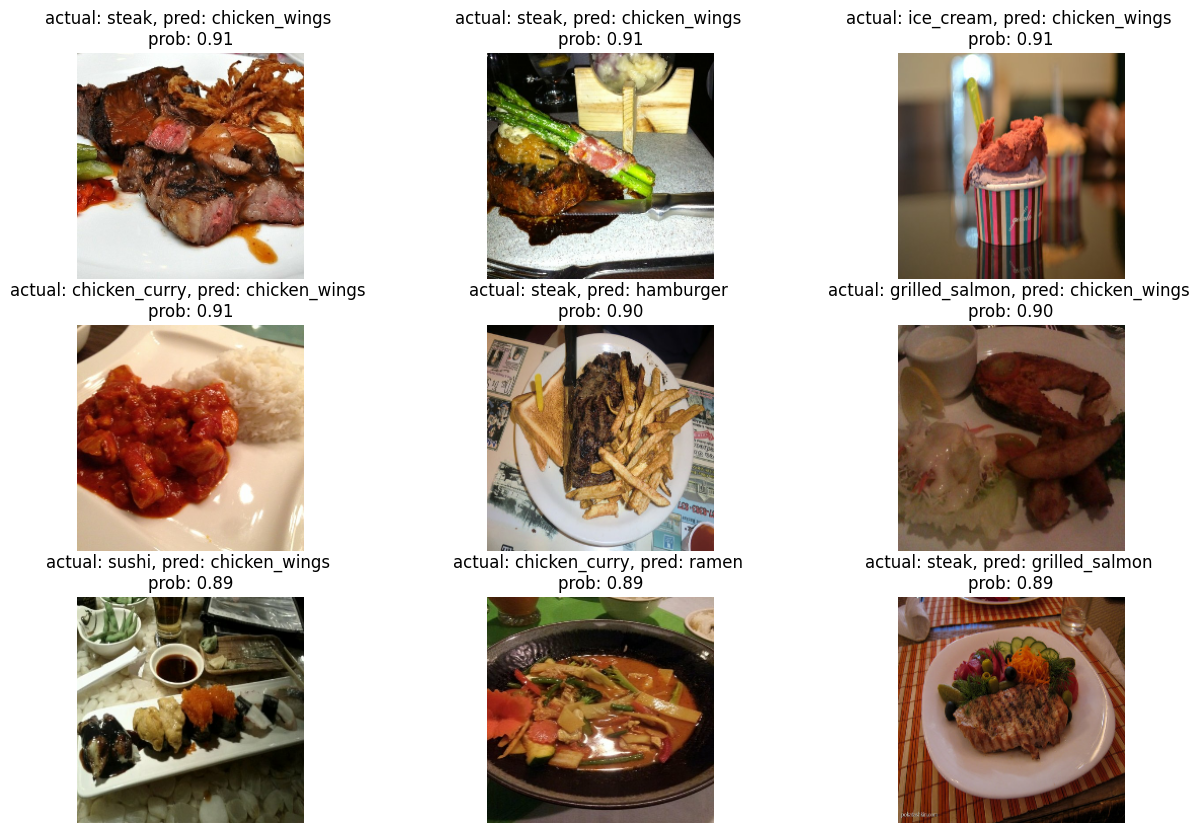

In [26]:
from helper_functions import load_and_prep_image

images_to_view = 9
start_index = 20 # change the start index to view more
plt.figure(figsize=(15, 10))

for i, row in enumerate(top_wrongs[start_index:start_index+images_to_view].itertuples()):
      plt.subplot(3, 3, i+1)
      img = load_and_prep_image(row[1], scale=True)
      _, _, _, _, pred_prob, y_true, y_pred, _ = row # only interested in a few parameters of each row
      plt.imshow(img)
      plt.title(f"actual: {y_true}, pred: {y_pred} \nprob: {pred_prob:.2f}")
      plt.axis(False)

---